#**Autism Prediction**

Latar belakang: Autisme adalah salah satu disorder yang belum memiliki metode pasti untuk diagnosis. <br>

Solusi: Machine Learning hadir untuk membantu memprediksi apakah seseorang terindikasi Autisme atau tidak

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

## Step 1: Importing Libraries and Dataset

In [2]:
# Import Dataset
df = pd.read_csv('train.csv')
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [3]:
# Cek dimensi
df.shape

(800, 22)

In [4]:
# cek informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [5]:
# Deksripsi probabilitas
df.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [6]:
# cek distribusi 'relation'
df.relation.value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


## Step 2: Data Cleaning

In [7]:
df.ethnicity.value_counts()

,count
ethnicity,
White-European,257
?,203
Middle Eastern,97
Asian,67
Black,47
South Asian,34
Pasifika,32
Others,29
Latino,17


In [8]:
df.relation.value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


Catatan: Terdapat kolom yang terisi "?" dan "Others" yang mengindikasikan ketidaktahuan valuenya. <br>

Selain itu kita juga bisa melakukan konfersi atau label encoding manual dari data2 yang bernilai 'yes' atau 'no' ke 1 atau 0

In [9]:
df = df.replace({
    'yes':1,
    'no':0,
    '?':'Others',
    'others':'Others'
})

df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,Others,0,0,Austria,0,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,Others,0,0,India,0,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,0,1,United States,0,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,Others,0,0,United States,0,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,Others,0,0,South Africa,0,-4.777286,18 and more,Self,0


In [10]:
df.relation.value_counts()

,count
relation,
Self,709
Others,42
Parent,29
Relative,18
Health care professional,2


## Step 3: Exploratory Data Analysis

In [11]:
# Target Values Distribution
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


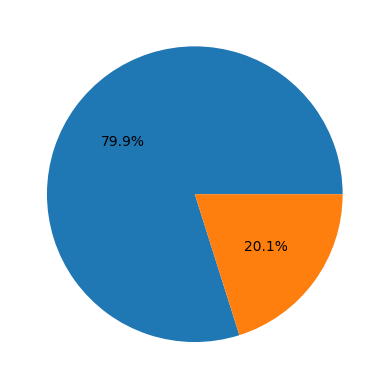

In [12]:
plt.pie(df['Class/ASD'].value_counts().values, autopct='%1.1f%%')
plt.show()

In [13]:
# Memisahkan tipe data angka, desimal, dan objek
ints = []
objects = []
floats = []

for i in df.columns:
  if df[i].dtype == int:
    ints.append(i)
  elif df[i].dtype == object:
    objects.append(i)
  else:
    floats.append(i)

In [14]:
# list ints
print(ints)

# list objects
print(objects)

# list floats
print(floats)

['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'jaundice', 'austim', 'used_app_before', 'Class/ASD']
['gender', 'ethnicity', 'contry_of_res', 'age_desc', 'relation']
['age', 'result']


In [15]:
# hapus ID dan Class/ASD dari list -> ID adalah unique value (identity) lalu Class/ASD adalah target
ints.remove('ID')
ints.remove('Class/ASD')

In [16]:
len(ints)

13

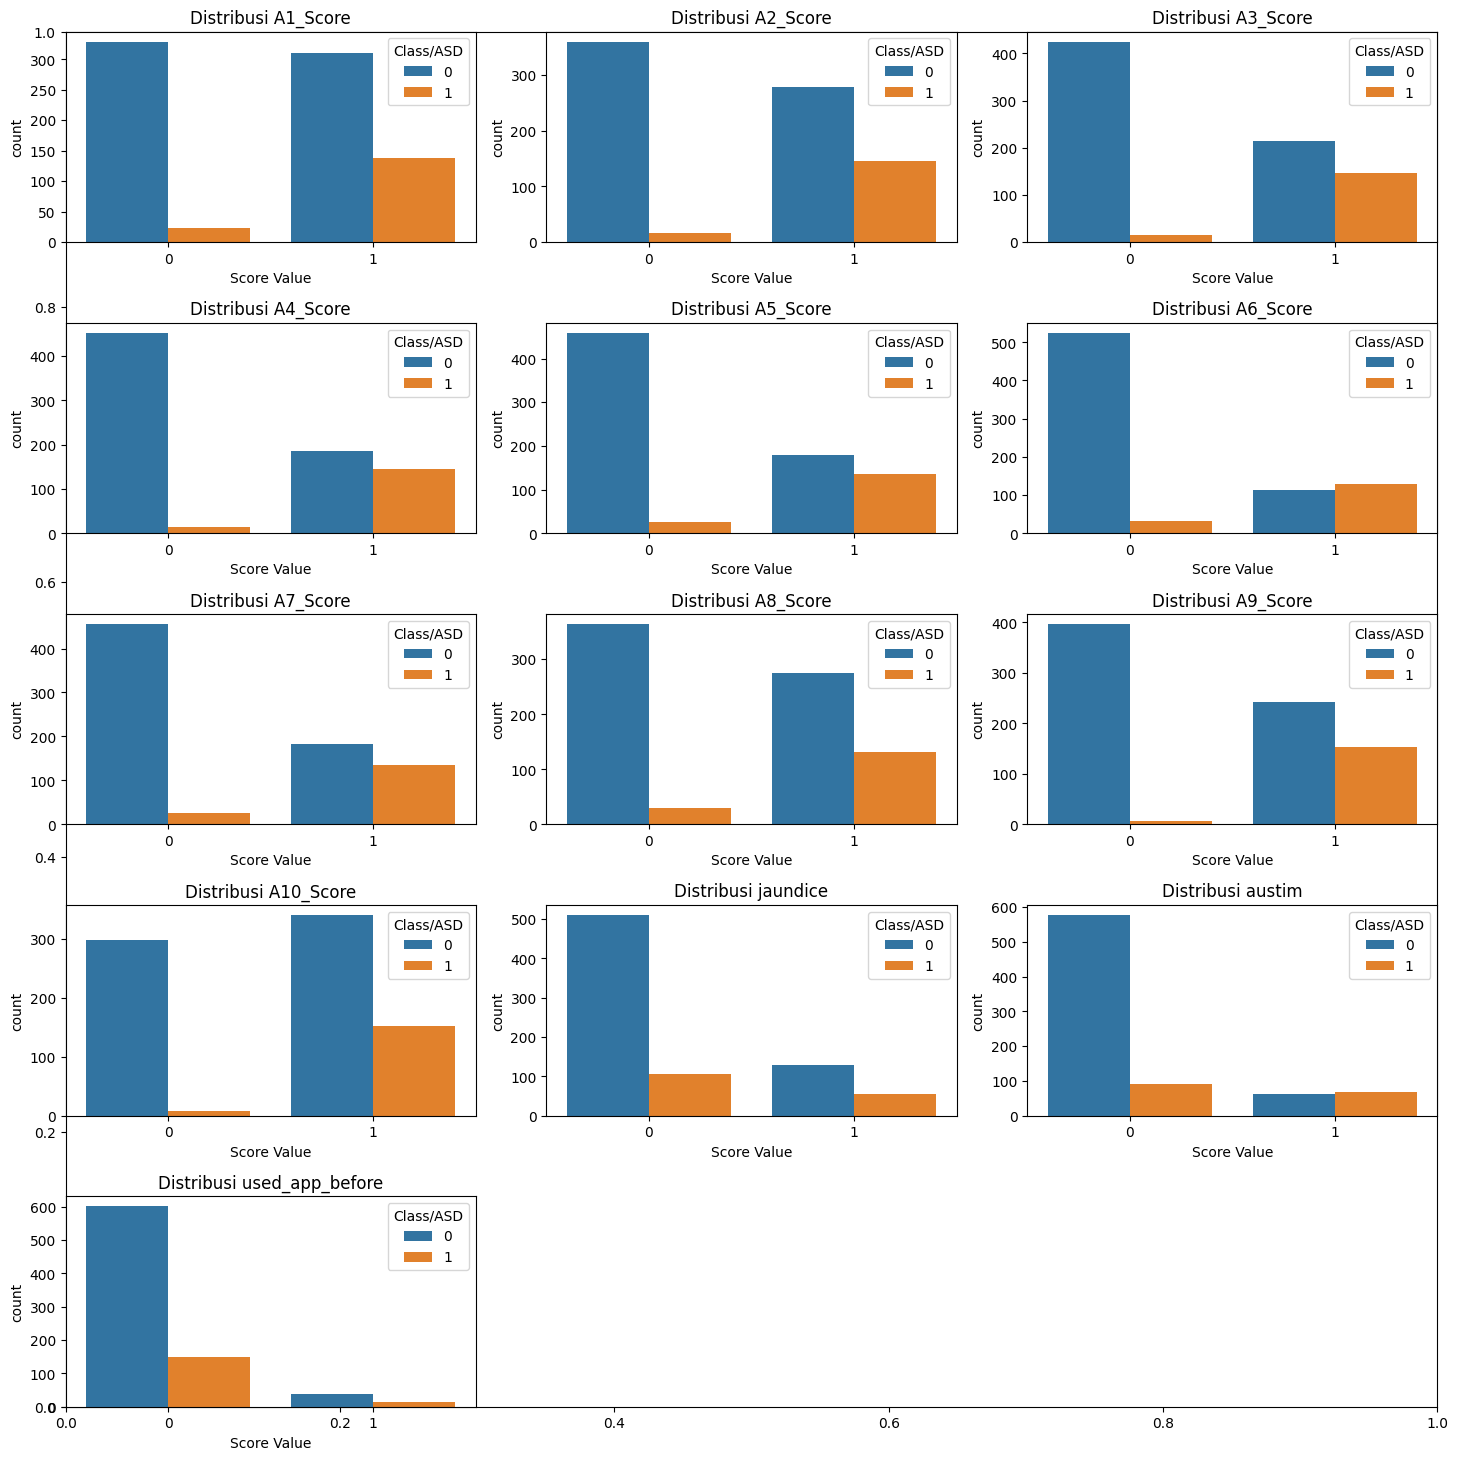

In [17]:
# VISUALISASI UNTUK DATA INTEGER
# Konfersi data wide form ke long form untuk lebih mudah divisualisasikan
df_melted = df.melt(id_vars=['ID', 'Class/ASD'], value_vars=ints,
                    var_name='col', value_name='value')

plt.subplots(figsize=(15, 15))

for i, col in enumerate(ints):
  plt.subplot(5, 3, i+1)

  sb.countplot(x='value', hue='Class/ASD', data=df_melted[df_melted['col'] == col])
  plt.title(f'Distribusi {col}')
  plt.xlabel('Score Value')
plt.tight_layout()
plt.show()

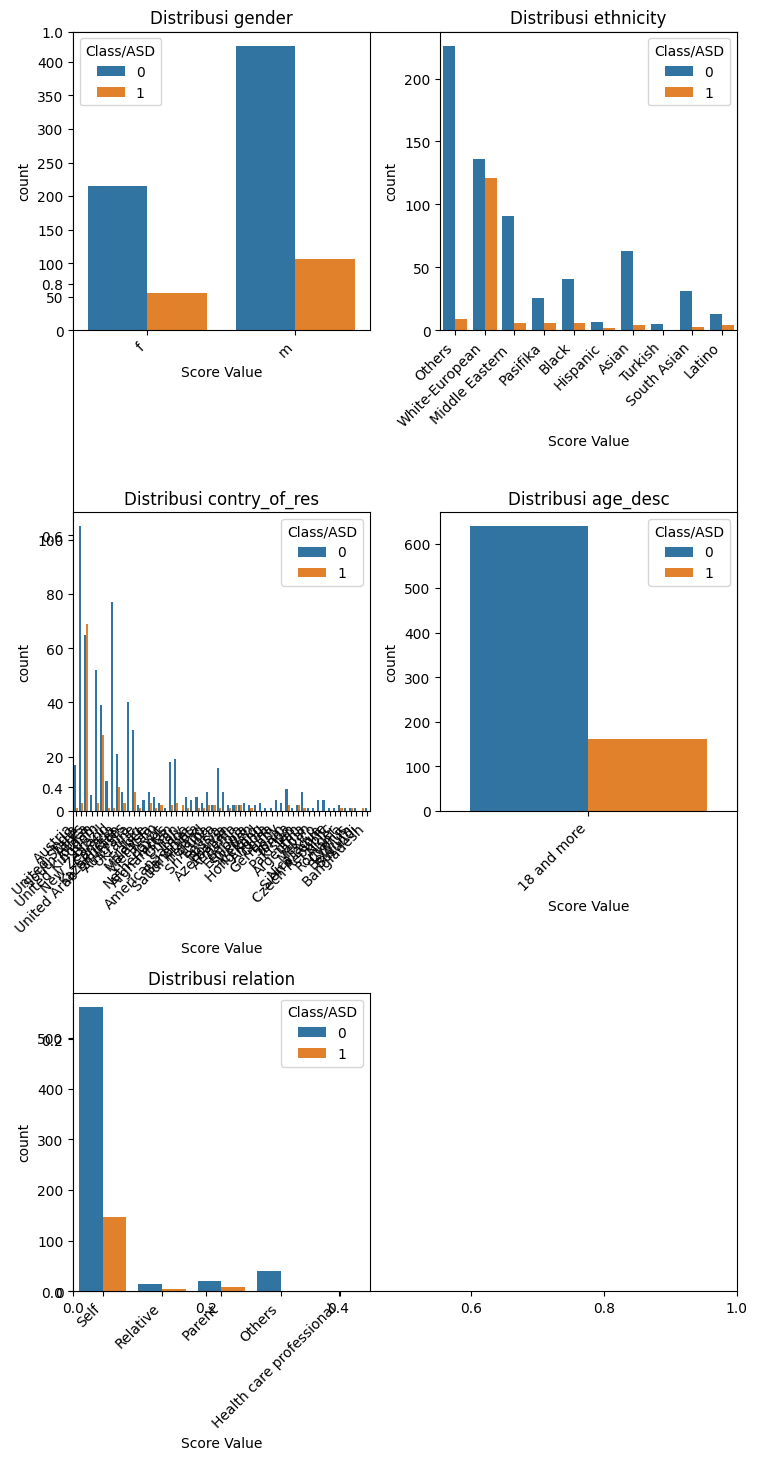

In [18]:
# VISUALISASI UNTUK DATA OBJECT
df_melted_obj = df.melt(id_vars=['ID', 'Class/ASD'], value_vars=objects,
                    var_name='col', value_name='value')
plt.subplots(figsize=(8, 15))

for i, col in enumerate(objects):
  plt.subplot(3, 2, i+1)

  sb.countplot(x='value', hue='Class/ASD', data=df_melted_obj[df_melted_obj['col'] == col])
  plt.title(f'Distribusi {col}')
  plt.xlabel('Score Value')
  plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Distribusi dilihat dari negara
country_stats = df.groupby(['contry_of_res', 'Class/ASD']).size().reset_index(name='count')
print_out = country_stats[country_stats['Class/ASD'] == 1].sort_values(by='count', ascending=False)
print(print_out.head())

     contry_of_res  Class/ASD  count
84   United States          1     69
82  United Kingdom          1     28
25          Canada          1      9
10       Australia          1      7
1      Afghanistan          1      3


Summary:

1. Distribusi pria yang diprediksi Autis lebih banyak dibandingkan perempuan
2. Etnis dengan distribusi autism terbesar adalah White-European
3. Negara dengan autism tertinggi adalah US = 69, disusul UK = 28


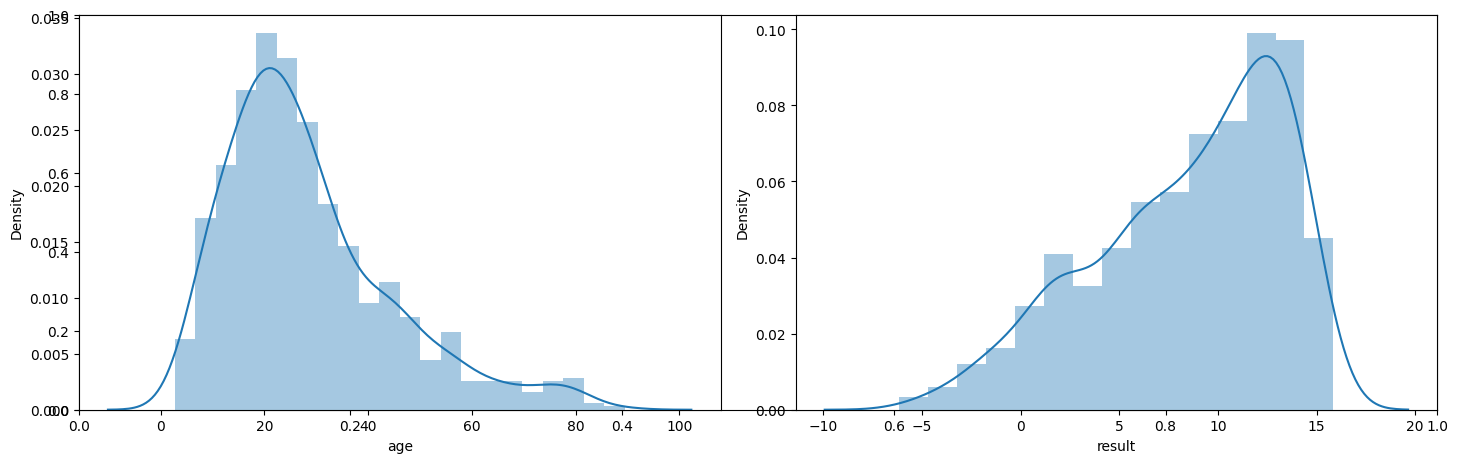

In [20]:
# Melihat sebaran data pada data floats
plt.subplots(figsize=(15,5))
for i, col in enumerate(floats):
  plt.subplot(1, 2, i+1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()

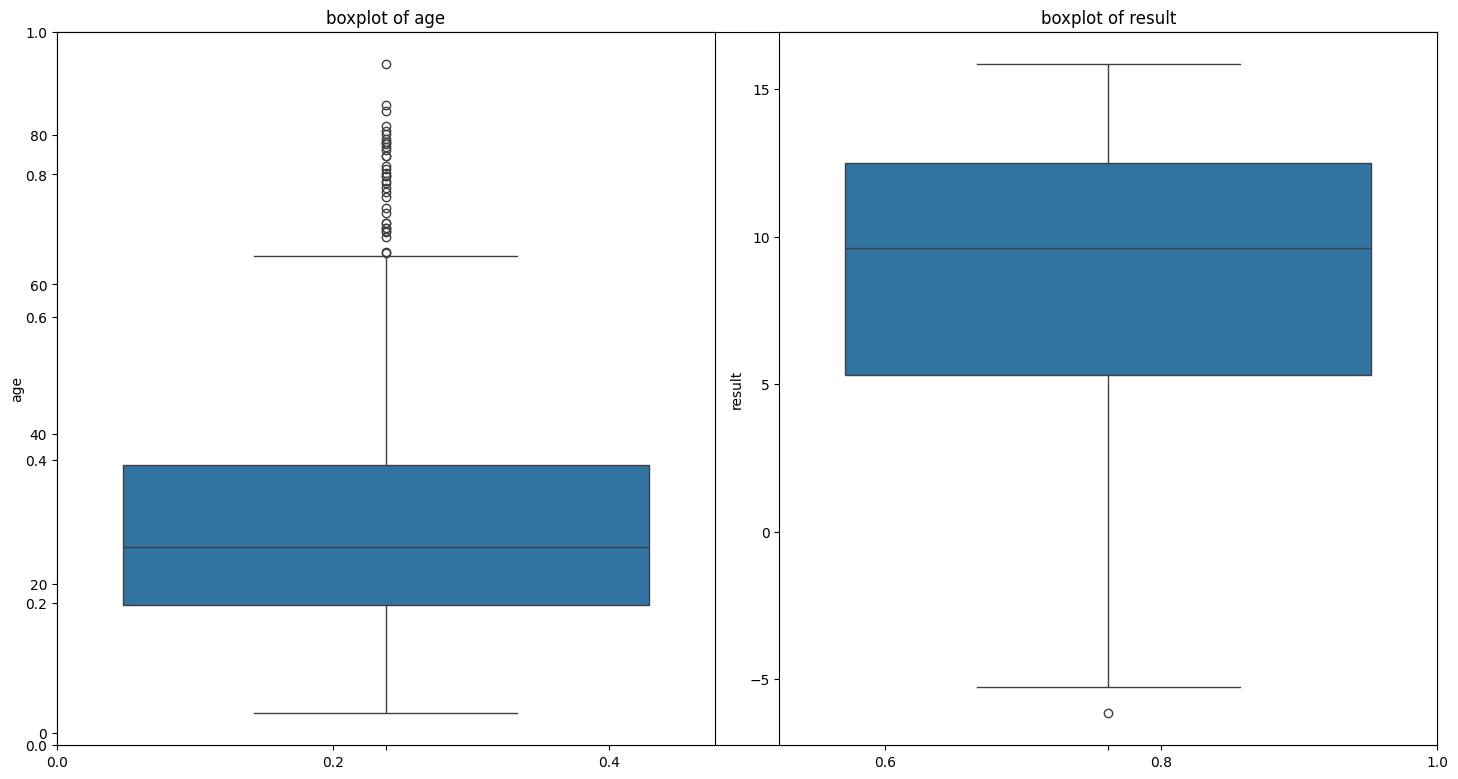

In [21]:
plt.subplots(figsize=(15, 8))

for i, col in enumerate(floats):
  plt.subplot(1, 2, i+1)
  sb.boxplot(df[col])
  plt.title(f'boxplot of {col}')
plt.tight_layout()
plt.show()

In [22]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


In [23]:
df_age_test_yes = df[(df['age'] > 60) & (df['Class/ASD'] == 1)]
print('Sampel Yes = ', df_age_test_yes.shape)
df_age_test_no = df[(df['age'] > 60) & (df['Class/ASD'] == 0)]
print('Sampel No = ', df_age_test_no.shape)

Sampel Yes =  (13, 22)
Sampel No =  (33, 22)


Summary Floats:
1. Data age/usia menunjukkan bahwa distribusi skew kanan. Yang berarti sampel pengujian rata-rata adalah 28 tahun (nilai asli >= 28 tahun)
2. Data result menunjukkan skew kiri namun terlihat tanpa outlier. Masih dalam range yang normal
3. Terdapat 13 sampel Yes dari outlier feature age. Total 46 sampel.
4. Jika di drop maka akan kehilangan sekitar 46 sampel, tersisa 125 sampel kelas Yes. Maka sebaiknya KEEP dengan catatan nanti gunakan MODEL YANG OUTLIERS FRIENDLY

## Step 4: Feature Engineering

In [24]:
# Membuat feature baru dari pengelompokkan AGE
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age >= 4 and age < 12:
        return 'Kid'
    elif age >= 12 and age < 18:
        return 'Teenager'
    elif age >= 18 and age < 40:
        return 'Adult'
    else:
        return 'Senior'
df['ageGroup'] = df['age'].apply(convertAge)

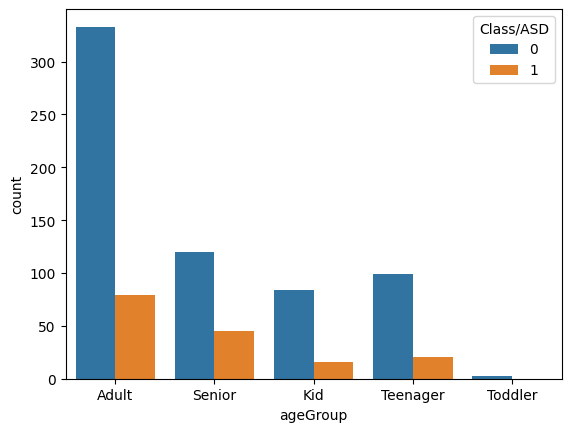

In [25]:
# Cek kasus dari Feature baru
sb.countplot(x = df['ageGroup'], hue = df['Class/ASD'])
plt.show()

Kelompok anak-anak dan balita memiliki peluang lebih rendah untuk mengidap autisme.

In [26]:
# Penjumlahan Skor Klinis
def add_clinic_feature(data):
  data['sum_score'] = 0
  for col in data.loc[:, 'A1_Score':'A10_Score'].columns:
    data['sum_score'] += data[col]

  data['ind'] = data['austim'] + data['used_app_before'] + data['jaundice']

  return data

df = add_clinic_feature(df)
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD,ageGroup,sum_score,ind
0,1,1,0,1,0,1,0,1,0,1,...,0,Austria,0,6.351166,18 and more,Self,0,Adult,6,0
1,2,0,0,0,0,0,0,0,0,0,...,0,India,0,2.255185,18 and more,Self,0,Senior,0,0
2,3,1,1,1,1,1,1,1,1,1,...,1,United States,0,14.851484,18 and more,Self,1,Kid,10,1
3,4,0,0,0,0,0,0,0,0,0,...,0,United States,0,2.276617,18 and more,Self,0,Adult,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,South Africa,0,-4.777286,18 and more,Self,0,Senior,0,0


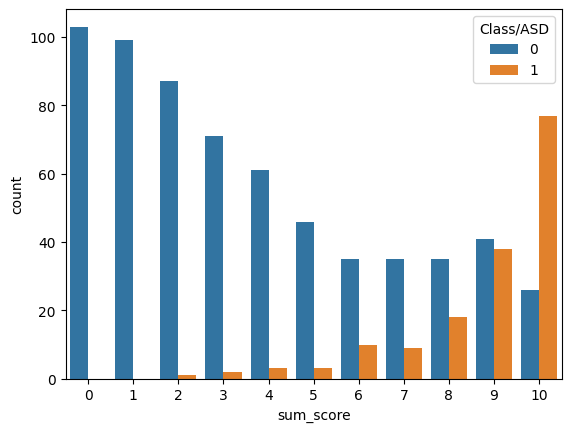

In [27]:
sb.countplot(x=df['sum_score'], hue=df['Class/ASD'])
plt.show()

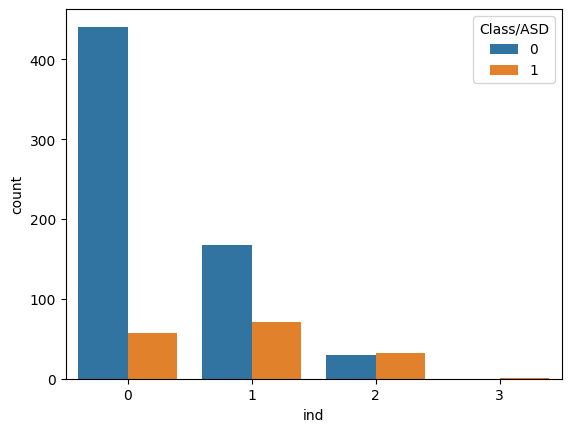

In [28]:
sb.countplot(x=df['ind'], hue=df['Class/ASD'])
plt.show()

Semakin besar total penjumlahan faktor klinis maka semakin tinggi kemungkinan mengidap autisme

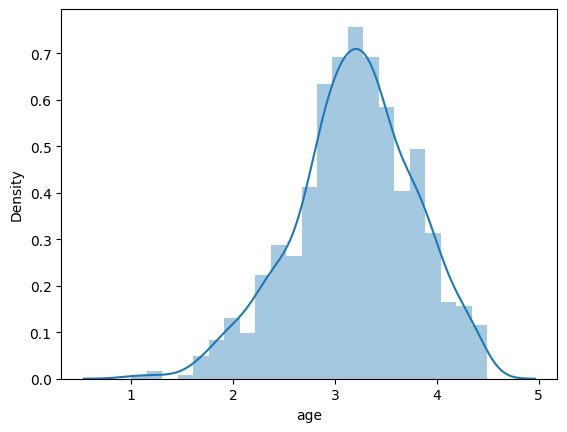

In [29]:
# Penerapan Log Transfor untuk menormalkan distribusi data age
df['age'] = df['age'].apply(lambda x: np.log(x))
sb.distplot(df['age'])
plt.show()

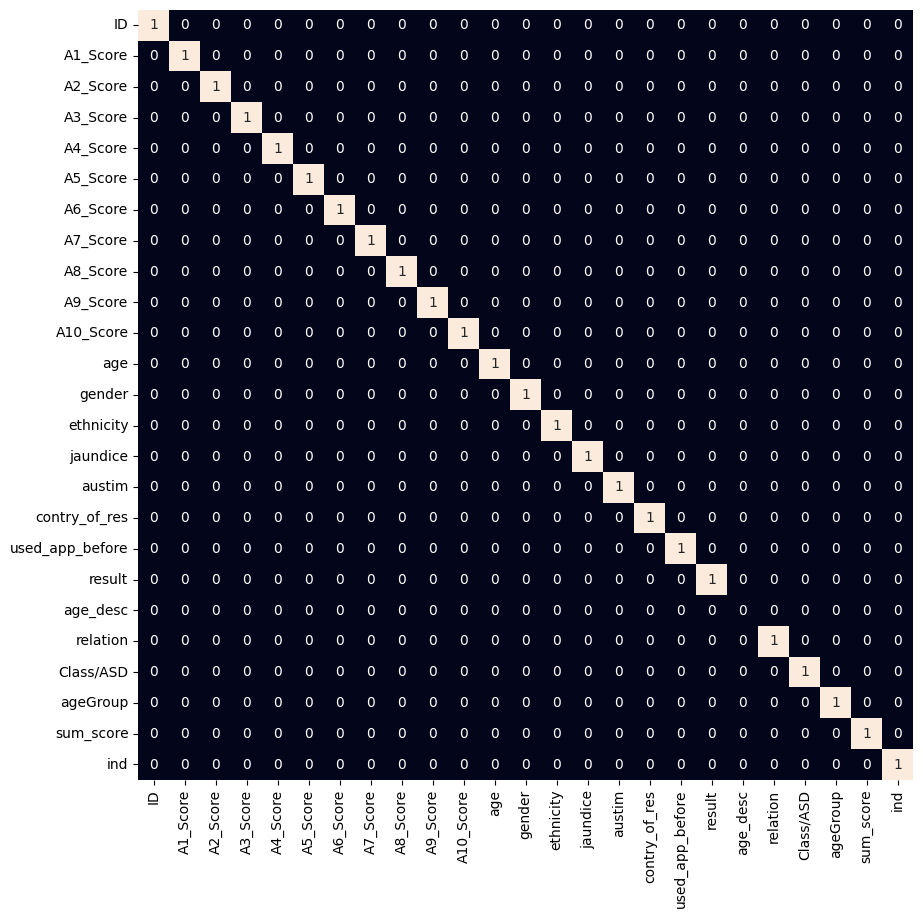

In [31]:
# Label Encoding
def encode_labels(data):
  for col in data.columns:
    if data[col].dtype == 'object':
      le = LabelEncoder()
      data[col] = le.fit_transform(data[col])
  return data

df = encode_labels(df)
plt.figure(figsize=(10,10))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

## Step 5: Model Training

In [32]:
# Memilih feature untuk training
removal = ['ID', 'age_desc', 'used_app_before', 'austim']
features = df.drop(removal + ['Class/ASD'], axis=1)
target = df['Class/ASD']

In [33]:
X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size = 0.2, random_state=10)

# Imbalanced data handling
ros = RandomOverSampler(sampling_strategy='minority',random_state=0)
X, Y = ros.fit_resample(X_train,Y_train)
X.shape, Y.shape

((1028, 20), (1028,))

In [34]:
Y.value_counts()

,count
Class/ASD,
0,514
1,514


In [35]:
scaler = StandardScaler()
X_scal = scaler.fit_transform(X)
X_val = scaler.transform(X_val)

In [39]:
# Definisikan model
models = [LogisticRegression(), XGBClassifier(), DecisionTreeClassifier()]

for model in models:
  model.fit(X_scal, Y)

  print(f'{model} : ')
  print(f'ROC AUC Score Train : ', metrics.roc_auc_score(Y, model.predict(X)))
  print(f'Classification Report Train: \n', metrics.classification_report(Y, model.predict(X)))
  print(f'ROC AUC Score Val : ', metrics.roc_auc_score(Y_val, model.predict(X_val)))
  print(f'Classification Report Val: \n', metrics.classification_report(Y_val, model.predict(X_val)))
  print('===============================================================================')

LogisticRegression() : 
ROC AUC Score Train :  0.5019455252918288
Classification Report Train: 
               precision    recall  f1-score   support

           0       1.00      0.00      0.01       514
           1       0.50      1.00      0.67       514

    accuracy                           0.50      1028
   macro avg       0.75      0.50      0.34      1028
weighted avg       0.75      0.50      0.34      1028

ROC AUC Score Val :  0.8142857142857144
Classification Report Val: 
               precision    recall  f1-score   support

           0       0.94      0.80      0.87       125
           1       0.54      0.83      0.65        35

    accuracy                           0.81       160
   macro avg       0.74      0.81      0.76       160
weighted avg       0.85      0.81      0.82       160

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_st

**Summary**

**`Logistic Regression`** <br>
ROC AUC Train = 0.50 <br>
ROC AUC Val = 0.81 <br><br>

**`XGBoost`** <br>
ROC AUC Train = 0.80 <br>
ROC AUC Val = 0.73 <br><br>

**`DecisionTree`** <br>
ROC AUC Train = 0.49 <br>
ROC AUC Val = 0.65 <br><br>

Dalam perbandingan tiga model di atas
1. Logistic Regression memiliki peningkatan signifikan pada saat tahap validasi, disusul oleh DecissionTree
2. Model XGBoost justru mengalami deaccuracy sebesar 7% dari accuracy Train.
<br>

Melihat hal tersebut, model **`Logistic Regression adalah pilihan terbaik untuk kasus prediksi Autisme ini`**